In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "6"

In [2]:
from functools import partial
from pathlib import Path

import datasets as hfds
import torch
import numpy as np
import torchvision.transforms.v2 as v2
from torch.utils.data import DataLoader, Subset
from matplotlib import pyplot as plt
from PIL import Image

import flat_mae.transforms as flat_transforms
import flat_mae.data as flat_data
import flat_mae.models_mae as models_mae
import flat_mae.masking as masking
import flat_mae.utils as ut
import flat_mae.nisc as nisc

/admin/home/connor/fmri-fm/.venv/lib/python3.11/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [3]:
plt.style.use("../clane.mplstyle")
plt.rcParams["figure.dpi"] = 200
plt.rcParams["savefig.dpi"] = 200
PLOTW = 3.25  # 6.75 two column width, 0.25 pad

In [4]:
def prefix_crop(sample, num_frames: int = 16):
    sample["bold"] = sample["bold"][:num_frames]
    return sample


def make_transform(space: str = "flat"):
    # hack, have to redefine to exclude center crop bc mni clips is only 16 frames
    # (idk why ig I forgot to make it 24 frames like the others)
    transform = v2.Compose(
        [
            flat_transforms.ToTensor(),
            prefix_crop,
            flat_transforms.Normalize(mode="frame"),
            flat_transforms.Clip(vmax=3.0),
            flat_transforms.get_unmask(space),
        ]
    )
    return transform

In [5]:
dataset_root = "s3://medarc/fmri-datasets/eval"
input_spaces = ["schaefer400", "flat", "mni_cortex"]

rng = np.random.default_rng(42)
num_examples = 16
indices = rng.choice(2000, num_examples, replace=False)

loaders = {}

img_sizes = {
    "schaefer400": (400, 1),
    "flat": (224, 560),
    "mni_cortex": (466, 512),
}
patch_sizes = {
    "schaefer400": 1,
    "flat": 16,
    "mni_cortex": (1, 512),
}

for space in input_spaces:
    transform = make_transform(space)
    dataset = hfds.load_dataset(
        "arrow",
        data_files=f"{dataset_root}/hcpya-clips.{space}.arrow/test/*.arrow",
        split="train",
    )
    dataset = flat_data.HFDataset(dataset, transform)
    dataset = Subset(dataset, indices)
    # note, hardcoded values from config, be careful
    mask_fn = masking.create_masking(
        name="tube",
        mask_ratio=0.9,
        img_size=img_sizes[space],
        patch_size=patch_sizes[space],
        num_frames=16,
        t_patch_size=4,
    )
    collate_fn = partial(masking.mask_collate, mask_fn=mask_fn)
    loaders[space] = DataLoader(
        dataset,
        batch_size=1,
        collate_fn=collate_fn,
        shuffle=False,
        num_workers=8,
        drop_last=False,
    )

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

In [7]:
def plot_mask_pred_from_state(bold, mask, state, space, nsamples=4, stride=2):
    unmask = flat_transforms.get_unmask(space)

    plot_state = {
        "image": bold,
        "target": state["targets"],
        "pred": state["pred_images"],
        "visible_mask": state["visible_mask"],
        "img_mask": mask.expand_as(bold),
    }
    for key, values in plot_state.items():
        if values is not None:
            # [B, C, T, H, W] -> [T, H, W],  C always 1
            values = values[0, 0, : nsamples * stride : stride].cpu()
            values = unmask.to_flat(values)
            plot_state[key] = values.numpy()

    fig = plot_mask_pred_row(**plot_state)
    return fig

In [8]:
def plot_mask_pred_row(
    image: np.ndarray,
    target: np.ndarray,
    pred: np.ndarray,
    visible_mask: np.ndarray,
    pred_mask: np.ndarray | None = None,
    img_mask: np.ndarray | None = None,
    paste_visible: bool = True,
):
    if img_mask is None:
        img_mask = np.ones_like(visible_mask)
    if pred_mask is None:
        pred_mask = img_mask * (1 - visible_mask)

    image_masked = image * visible_mask
    pred_masked = pred * pred_mask
    if paste_visible:
        pred_masked = (1 - pred_mask) * image_masked + pred_mask * pred

    T, H, W = target.shape
    ploth = 2.0
    plotw = (W / H) * ploth
    nrow = 3
    ncol = T
    fig, axs = plt.subplots(nrow, ncol, figsize=(plotw * ncol, ploth * nrow), squeeze=False)

    for ii in range(T):
        plt.sca(axs[0, ii])
        _imshow(image_masked[ii], img_mask[ii])

        plt.sca(axs[1, ii])
        _imshow(pred_masked[ii], img_mask[ii])

        plt.sca(axs[2, ii])
        _imshow(target[ii], img_mask[ii])

    # plt.tight_layout(pad=0.0, w_pad=0.25, h_pad=1.0)
    fig.subplots_adjust(
        left=0.0,
        right=1.0,
        bottom=0.0,
        top=1.0,
        wspace=0.02,
        hspace=0.02,
    )
    return fig


def _imshow(image, mask):
    plt.imshow(
        np.where(mask, image, np.nan), cmap=nisc.FC_CMAP, vmin=-3, vmax=3, interpolation="none"
    )
    plt.axis("off")

In [9]:
device = torch.device("cuda")

In [10]:
models = {}

for space in input_spaces:
    ckpt_path = f"output/input_space/{space}/pretrain/checkpoint-last.pth"
    models[space] = models_mae.MaskedAutoencoderViT.from_checkpoint(ckpt_path).to(device)

In [11]:
batch = next(iter(loaders["flat"]))
bold = batch["bold"].to(device)
mask = batch["mask"].to(device)
visible_mask = batch["visible_mask"].to(device)
_, state = models["flat"](
    bold, img_mask=mask, visible_mask=visible_mask, mask_ratio=0.9, with_state=True
)

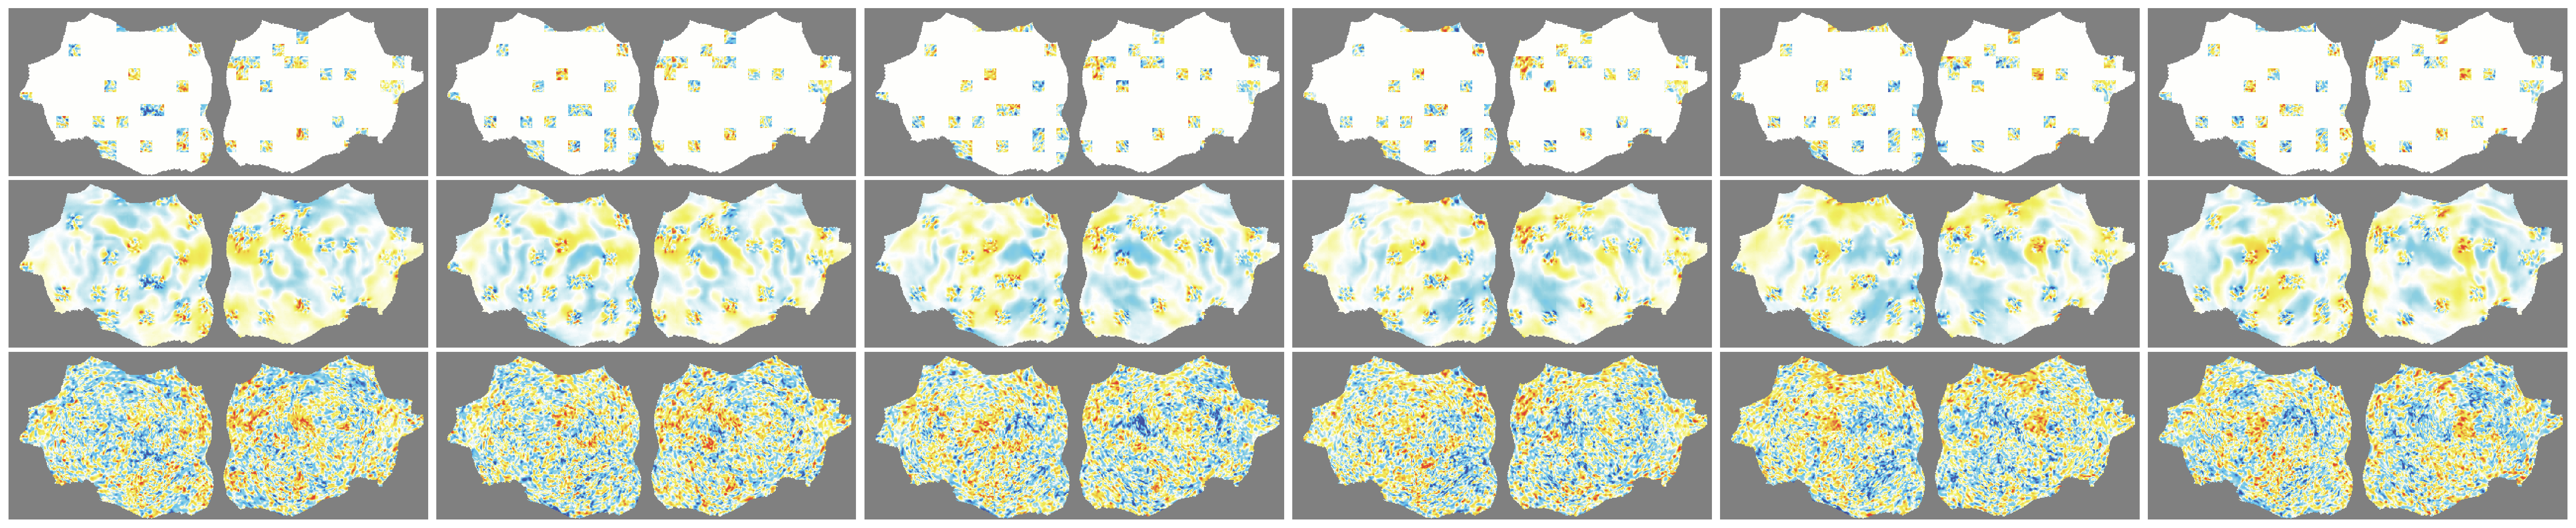

In [12]:
f = plot_mask_pred_from_state(bold, mask, state, "flat", nsamples=6);

In [13]:
outdir = Path("results/recons")
outdir.mkdir(exist_ok=True, parents=True)

In [30]:
nsamples = 1

with torch.inference_mode():
    for space in input_spaces:
        loader = loaders[space]
        model = models[space]
        ut.random_seed(42)
        for ii, (idx, batch) in enumerate(zip(indices, loader)):
            bold = batch["bold"].to(device)
            mask = batch["mask"].to(device)
            visible_mask = batch["visible_mask"].to(device)
            _, state = model(
                bold, img_mask=mask, visible_mask=visible_mask, mask_ratio=0.9, with_state=True
            )

            f = plot_mask_pred_from_state(bold, mask, state, space, nsamples=nsamples)
            f.savefig(
                outdir / f"recon_{space}_{ii:02d}_{idx:04d}.png",
                dpi=100,
                bbox_inches="tight",
                pad_inches=0,
            )
            plt.close(f)

In [15]:
space_names = {
    "schaefer400": "parcel",
    "flat": "flat",
    "mni_cortex": "volume",
}

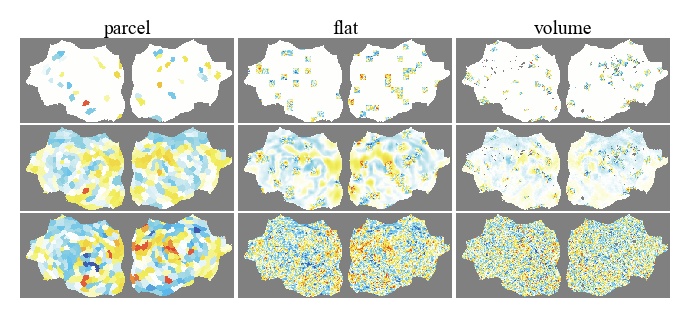

In [39]:
# nice examples: 0, 2, 7, 8, 9, 11, 13, 14

example_id = 0
example_idx = indices[example_id]

H, W = 224, 560
figw = PLOTW
plotw = figw / 3
ploth = (H / W) * plotw
figh = 3 * ploth
f, axs = plt.subplots(1, 3, figsize=(figw, figh))

for ii, ax in enumerate(axs):
    plt.sca(ax)
    space = input_spaces[ii]
    path = outdir / f"recon_{space}_{example_id:02d}_{example_idx:04d}.png"
    img = Image.open(path)
    plt.imshow(img, interpolation="none")
    plt.axis("off")
    plt.title(space_names[space], fontsize="medium", pad=0)

f.subplots_adjust(
    left=0.0,
    right=1.0,
    bottom=0.0,
    top=1.0,
    wspace=0.02,
    hspace=0.02,
)

f.savefig(
    outdir / f"recon_all_spaces_{example_id:02d}_{example_idx:04d}.pdf",
    bbox_inches="tight",
    pad_inches=0,
)

In [38]:
space = "flat"

nsamples = 6

with torch.inference_mode():
    loader = loaders[space]
    model = models[space]
    ut.random_seed(42)
    for ii, (idx, batch) in enumerate(zip(indices, loader)):
        bold = batch["bold"].to(device)
        mask = batch["mask"].to(device)
        visible_mask = batch["visible_mask"].to(device)
        _, state = model(
            bold, img_mask=mask, visible_mask=visible_mask, mask_ratio=0.9, with_state=True
        )

        f = plot_mask_pred_from_state(bold, mask, state, space, nsamples=nsamples)
        f.savefig(
            outdir / f"recon_{space}_n{nsamples}_{ii:02d}_{idx:04d}.png",
            dpi=100,
            bbox_inches="tight",
            pad_inches=0,
        )
        plt.close(f)
        if ii >= 4:
            break

In [36]:
nsd_loaders = {}

for space in ["flat"]:
    transform = make_transform(space)
    dataset = hfds.load_dataset(
        "arrow",
        data_files=f"{dataset_root}/nsd-cococlip.{space}.arrow/testid/*.arrow",
        split="train",
    )
    dataset = flat_data.HFDataset(dataset, transform)
    dataset = Subset(dataset, indices)
    # note, hardcoded values from config, be careful
    mask_fn = masking.create_masking(
        name="tube",
        mask_ratio=0.9,
        img_size=img_sizes[space],
        patch_size=patch_sizes[space],
        num_frames=16,
        t_patch_size=4,
    )
    collate_fn = partial(masking.mask_collate, mask_fn=mask_fn)
    nsd_loaders[space] = DataLoader(
        dataset,
        batch_size=1,
        collate_fn=collate_fn,
        shuffle=False,
        num_workers=8,
        drop_last=False,
    )

Resolving data files:   0%|          | 0/54 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/27 [00:00<?, ?it/s]

In [37]:
space = "flat"

nsamples = 6

with torch.inference_mode():
    loader = nsd_loaders[space]
    model = models[space]
    ut.random_seed(42)
    for ii, (idx, batch) in enumerate(zip(indices, loader)):
        bold = batch["bold"].to(device)
        mask = batch["mask"].to(device)
        visible_mask = batch["visible_mask"].to(device)
        _, state = model(
            bold, img_mask=mask, visible_mask=visible_mask, mask_ratio=0.9, with_state=True
        )

        f = plot_mask_pred_from_state(bold, mask, state, space, nsamples=nsamples)
        f.savefig(
            outdir / f"recon_nsd_{space}_n{nsamples}_{ii:02d}_{idx:04d}.png",
            dpi=100,
            bbox_inches="tight",
            pad_inches=0,
        )
        plt.close(f)
        if ii >= 4:
            break